In [1]:
# Loading data


# Fit to size


# Load Model


# 

In [16]:
import requests
import pandas as pd
import numpy as np
from io import BytesIO
import PIL
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MinMaxScaler
from joblib import load
scaler = MinMaxScaler()



def scrape_single_day(date: str):
    """
    Scrape one Scrandle day into local memory only.

    Returns:
        df: pandas.DataFrame with one row per side
        images: dict mapping image_name -> processed PIL images
    """
    headers = {"User-Agent": "Mozilla/5.0"}
    url = f"https://scrandle.com/history/{date}"

    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()
    data = response.json()

    rows = []
    images_raw = []

    for i, (left, right) in enumerate(data["data"]):
        # LEFT
        left_img_url = left["images_new"][0]
        left_filename = f"{i}_left.webp"

        rows.append({
            "date": date,
            "match_id": i,
            "side": "left",
            "id": left.get("id"),
            "url": left.get("url"),
            "price": left.get("price"),
            "rating": left.get("rating"),
            "year": left.get("year"),
            "title": left.get("title", "").strip('"'),
            "subtitle": left.get("subtitle"),
            "club": left.get("club"),
            "country": left.get("country"),
            "image_name": left_filename,
            "image_url": left_img_url,
            "rating_source": left.get("rating_source"),
            "image_position": left.get("image_position"),
            "elo": left.get("elo"),
        })

        img_resp = requests.get(left_img_url, headers=headers, timeout=20)
        img_resp.raise_for_status()
        left_img = PIL.Image.open(BytesIO(img_resp.content)).convert("RGB")
        images_raw.append(np.array(left_img))

        # RIGHT
        right_img_url = right["images_new"][0]
        right_filename = f"{i}_right.webp"

        rows.append({
            "date": date,
            "match_id": i,
            "side": "right",
            "id": right.get("id"),
            "url": right.get("url"),
            "price": right.get("price"),
            "rating": right.get("rating"),
            "year": right.get("year"),
            "title": right.get("title", "").strip('"'),
            "subtitle": right.get("subtitle"),
            "club": right.get("club"),
            "country": right.get("country"),
            "image_name": right_filename,
            "image_url": right_img_url,
            "rating_source": right.get("rating_source"),
            "image_position": right.get("image_position"),
            "elo": right.get("elo"),
        })

        img_resp = requests.get(right_img_url, headers=headers, timeout=20)
        img_resp.raise_for_status()
        right_img = PIL.Image.open(BytesIO(img_resp.content)).convert("RGB")
        images_raw.append(np.array(right_img))

    metadata = pd.DataFrame(rows)
    return metadata, images_raw


def cut_image(image, resolution):
    height, width, _ = image.shape
    a, b = 6, 5
    target_height = height * a // b

    if target_height > width:
        new_width = width
        new_height = width * b // a
        cut_height1 = (height - new_height) // 2
        cut_height2 = (height + new_height) // 2
        new_image = image[cut_height1:cut_height2, :]
    else:
        new_height = height
        new_width = height * a // b
        cut_width1 = (width - new_width) // 2
        cut_width2 = (width + new_width) // 2
        new_image = image[:, cut_width1:cut_width2]

    pillow_image = PIL.Image.fromarray(new_image)
    final_image = PIL.ImageOps.fit(pillow_image, resolution, method=PIL.Image.BILINEAR)
    return final_image

def prepare_features(metadata, images_raw):
    tokendata = []
    for _, row in metadata.iterrows():
        tokendata.append(
            f"{row['title']} {row['subtitle'] or ''} {row['country']} {row['club']}"
        )

    ratings = torch.tensor(metadata["rating"].fillna(0).to_numpy(), dtype=torch.float32) / 100.0

    prices = metadata["price"].fillna(0).to_numpy(dtype=float)
    prices = torch.tensor(scaler.fit_transform(prices.reshape(-1, 1)).ravel(), dtype=torch.float32)

    vectorizer = load("vectorizer.joblib")
    tokens_csr = vectorizer.transform(tokendata)
    tokens = torch.tensor(tokens_csr.toarray(), dtype=torch.float32) / 3.0

    images = np.stack([np.array(img) for img in images_raw]).astype(np.float32)
    images = torch.from_numpy(images) / 255.0
    images = images.permute(0, 3, 1, 2)

    return images, prices, tokens, ratings

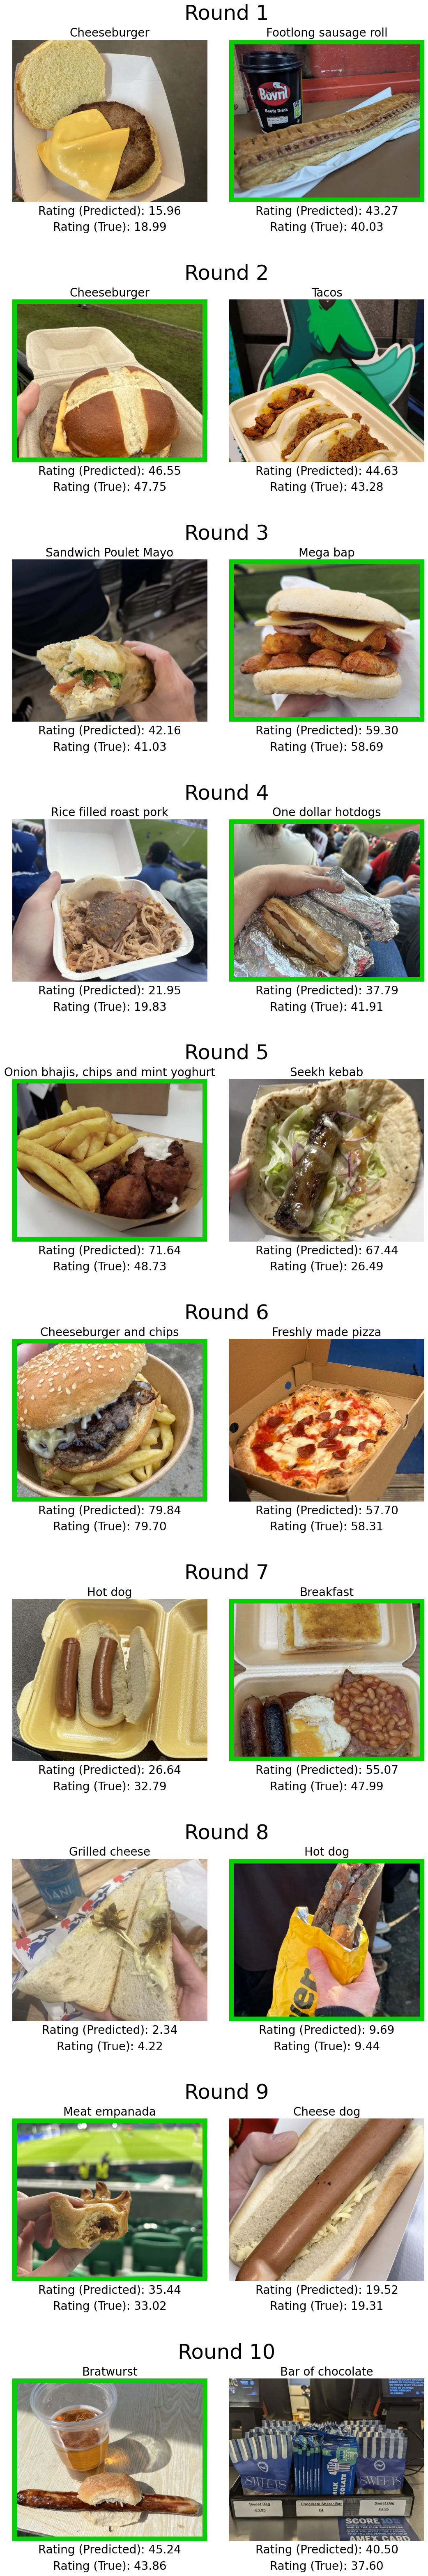

In [37]:
resolution = [102, 85]
metadata, images_raw = scrape_single_day("2026-05-30")
images_cut_low = [cut_image(image, resolution) for image in images_raw]
images, prices, tokens, ratings = prepare_features(metadata, images_cut_low)

n_tokens = tokens.shape[1]
class ImagePriceModel(nn.Module):
    def __init__(self, token_dim=n_tokens):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        image_branch = resnet50(weights=weights)
        self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])  # 2048 features



        joint_dim = 2048 + 1 + 3650
        self.head = nn.Sequential(
            nn.Linear(joint_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, price, token):
        img_feat = self.image_branch(image).flatten(1)                   
        x = torch.cat([img_feat, price, token], dim=1)
        return self.head(x)

    


model = ImagePriceModel(token_dim=n_tokens)
state_dict = torch.load("model_weights")
model.load_state_dict(state_dict)

model.eval()
pred_ratings = model(images, prices.unsqueeze(1), tokens).detach().cpu().squeeze().numpy()

fig, ax = plt.subplots(10, 2, figsize=(14, 70))
images_cut_high = [cut_image(image, [1200,1000]) for image in images_raw]
for i in range(10):
    left = 2 * i
    right = 2 * i + 1

    img1 = images_cut_high[left]
    img2 = images_cut_high[right]

    ax[i,0].imshow(img1)
    ax[i,0].set_title(metadata.iloc[left]["title"], fontsize=20)
    ax[i,0].text(0.5, -0.02, f"Rating (Predicted): {100 * pred_ratings[left]:.2f}", transform=ax[i,0].transAxes, ha="center", va="top", fontsize=20)
    ax[i,0].text(0.5, -0.12, f"Rating (True): {100 * ratings[left]:.2f}", transform=ax[i,0].transAxes, ha="center", va="top", fontsize=20)
    ax[i,0].axis("off")

    ax[i,1].imshow(img2)
    ax[i,1].set_title(metadata.iloc[right]["title"], fontsize=20)
    ax[i,1].text(0.5, -0.02, f"Rating (Predicted): {100 * pred_ratings[right]:.2f}", transform=ax[i,1].transAxes, ha="center", va="top", fontsize=20)
    ax[i,1].text(0.5, -0.12, f"Rating (True): {100 * ratings[right]:.2f}", transform=ax[i,1].transAxes, ha="center", va="top", fontsize=20)
    ax[i,1].axis("off")

    # row title above the pair
    ax[i,0].text(1.1, 1.1, f"Round {i+1}", transform=ax[i,0].transAxes, ha="center", va="bottom", fontsize=36)

    left_pred_wins = pred_ratings[left] > pred_ratings[right]
    frame_index = 0 if left_pred_wins else 1
    correct = left_pred_wins == (ratings[left] > ratings[right])
    frame_color = "#09CB06" if correct else "#FF0000"

    ax[i,frame_index].add_patch(Rectangle((0, 0), 1, 1, transform=ax[i,frame_index].transAxes, fill=False, edgecolor=frame_color, linewidth=16))

plt.subplots_adjust(top=0.98, hspace=0.6, wspace=-0.05)
plt.savefig("ScrandeSolved_2026_06_05.png")
plt.show()
